<img src="https://educationaltechnology.net/wp-content/uploads/2018/05/Fotolia_101012346_Subscription_Monthly_M-1068x580-1024x556.jpg"
     alt="Example image from Medium"
     width="600"
     height="300">



#**Predictive Modeling of Student Success in MOOC**




##**Group Members**

###Kelly (Wanjing) Chen

Email: w3chen@odu.edu

Web Portfolio: https://kellychen-data.github.io/

###Akul Dahiya

Email: aakul001@odu.edu

Web Portfolio: https://akul-dahiya.github.io








##**Raw Datasets**
 https://analyse.kmi.open.ac.uk/open-dataset

##**Abstract**
This project uses the Open University Learning Analytics Dataset (OULAD) to develop a model for identifying students at risk of failing Massive Open Online Courses (MOOCs) for early intervention. We engineered features capturing student demographics, online engagement, and assessment performance from the original dataset, and used these features to train classifiers to distinguish between students who pass or fail. The dataset is pre-labeled with students’ final results in the MOOC as pass, fail, withdrawn, or distinction, and these labels serve as the target variable for modeling. The data was split into 60% training and 40% testing sets using stratified sampling across course and delivery mode (spring/fall). Modeling results indicate that while Logistic Regression achieves slightly higher performance on standard evaluation metrics, reaching an overall accuracy of 0.81, the Random Forest model identifies a greater number of actual failing students—a metric more closely aligned with the project’s goal of early risk detection. To further improve model performance, we plan to incorporate aggregated assessment performance data to relabel the dataset, expanding the definition of at-risk students to include those who pass but achieve low grades, rather than only those who fail.




##**Project Plan**
**Data Profiling and Cleaning** -9/20/2025

**Descriptive Analysis and Visualization** -09/30/2025

**Inferential Analysis** -10/12/2025 (Progress Check 1)

**Model Testing** -10/22/2025

**Trouble Shooting** -11/9/2025 (Progress Check 2)

**Video Presentation** - 12/1/2025

**Final Results & Write-up** -12/5/2025


#**Workflow Organization**
To streamline workflow, we first created a shared project folder to organize data and code on Google Drive, and imported all the libraries needed for data processing.

In [ ]:
# create a shared Google Drive folder to organize data and code
from google.colab import drive
drive.mount('/content/drive')

import os
folder_path = '/content/drive/MyDrive/Ds620Final'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created successfully.")
else:
    print(f"Folder '{folder_path}' already exists.")

Mounted at /content/drive
Folder '/content/drive/MyDrive/Ds620Final' already exists.


In [ ]:
# import all the libraries needed for data processing
import numpy as np
import pandas as pd
from pandas import DataFrame, Series
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns



#**Preprocessing**
The OULAD datasets contains 7 csv files. We loaded each csv file into a dataframe, and created a dictionary "datasets" to store all the dataframes. We then created and applied a function "data_profiling" to all the dataframes in datasets, printing out the size of each dataframe, their column list, and the situation of missing data and duplicity. By reading the outputs with the metadata of the OULAD datasets, We built contextual understandings of our data and came up with a data preprocessing strategy to achieve our analytical goal.

In [ ]:

# Load all CSV files into DataFrames
assessments = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/assessments.csv")
courses = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/courses.csv")
studentAssessment = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/studentAssessment.csv")
studentInfo = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/studentInfo.csv")
studentRegistration = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/studentRegistration.csv")
studentVle = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/studentVle.csv")
vle = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/vle.csv")


#Create the dictionary of datasets
datasets = {
    "assessments": assessments,
    "courses": courses,
    "studentAssessment": studentAssessment,
    "studentInfo": studentInfo,
    "studentRegistration": studentRegistration,
    "studentVle": studentVle,
    "vle": vle
}

In [ ]:
# create a function for data profiling
def data_profiling(key_df):
  """
  Display an overview of multiple pandas DataFrames for data profiling.

    Parameters:
    key_df (dict): A dictionary where keys are table names (str) and values are pandas DataFrames.

    Returns:
    None: This function only prints and displays information; it does not return anything.

  """
  for key, df in key_df.items():
    print("Table Name:", key, '\n')
    display(df.head())
    print('\n')
    df.info()
    print('\npercentage of missing values:\n',df.isnull().sum()/df.shape[0]*100)
    print('\nduplicated value:',df.duplicated().sum())
    print('\n\n')

# apply data_profiling function to dictionary 'datasets'
data_profiling(datasets)

Table Name: assessments 



,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.8+ KB

percentage of missing values:
 code_module          0.000000
code_presentation    0.000000
id_assessment        0.000000
assessment_type      0.000000
date                 5.339806
weight               0.000000
dtype: float64

duplicated value: 0



Table Name: courses 



,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   code_module                 22 non-null     object
 1   code_presentation           22 non-null     object
 2   module_presentation_length  22 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 660.0+ bytes

percentage of missing values:
 code_module                   0.0
code_presentation             0.0
module_presentation_length    0.0
dtype: float64

duplicated value: 0



Table Name: studentAssessment 



...



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  object 
 1   code_presentation    32593 non-null  object 
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ MB

percentage of missing values:
 code_module             0.000000
code_presentation       0.000000
id_student              0.000000
date_registration       0.138066
date_unregistration    69.097659
dtype: float64

duplicated value: 0



Table Name: studentVle 



,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB

percentage of missing values:
 code_module          0.0
code_presentation    0.0
id_student           0.0
id_site              0.0
date                 0.0
sum_click            0.0
dtype: float64

duplicated value: 787170



Table Name: vle 



,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   object 
 2   code_presentation  6364 non-null   object 
 3   activity_type      6364 non-null   object 
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 298.4+ KB

percentage of missing values:
 id_site               0.000000
code_module           0.000000
code_presentation     0.000000
activity_type         0.000000
week_from            82.385292
week_to              82.385292
dtype: float64

duplicated value: 0





In [ ]:

# Data validation and missing value overview

print("Checking for missing values in studentAssessment before processing:")
print(studentAssessment.isnull().sum())

# Before computing averages or patterns, we check missing values to ensure data reliability.
# Missing values in 'score' can distort results.

# Handle outliers in scores (clip values between 0 and 100)
studentAssessment['score'] = studentAssessment['score'].clip(lower=0, upper=100)

# Check consistency: Ensure every student_id exists in studentInfo
missing_students = studentAssessment[~studentAssessment['id_student'].isin(studentInfo['id_student'])]
print(f"Records in studentAssessment with missing student info: {len(missing_students)}")


Checking for missing values in studentAssessment before processing:
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64
Records in studentAssessment with missing student info: 0


###**Interpretation of the Output**

The output showed that there were missing values in 5 of the 7 dataframes but no duplicates. The situation for each dataframes are listed below.

1) Courses: no missing value and duplicates.

2) vle: large percentage of missing values(82.5%) in week_from, week_to columns, no duplicates.

3) studentVle: no missing value, no duplicates.  

4) studentRegistration: 0.13% missing value in date_registration, 69% missing value in date_unregistration, no duplicates.

5) StudentInfo: 3% missing value in imd_band, no duplicates.

6) studentAssessment: 0.09% missing value in score, no duplicates.

7) assessments: 5% missing value in date, no duplicated value.

###**Handling Missing Value**

To understand why these missing values exist, we turn to the metadata of the OULAD datasets first. We need to know 1) how the data are collected, 2) what each field in each table stands for, and 3) how these tables are interelated, in order to handle missing value properly.  

<img src="https://analyse.kmi.open.ac.uk/resources/images/model.png"
     alt="Example image from Medium"
     width="600"
     height="500">

The figure above, drawn from the metadata documentation of the OULAD datasets, shows the content of each table and their inter-relation.

Accordingly, missing values in each table exist for the following reasons:

-vle: missing values(82.5%) in week_from, week_to columns means these course materials do not have a time limit on them in the course. These are likely general materials in an online course, rather than module material, assignments and exams that are available to student for a specific duration.

-studentRegistration: 69% missing value in date_unregistration. Only students who de-reisgered from the course would have value in data_unregistration. We will use this data to exclude students who deregistered from our analysis.

-studentRegistration: 0.13% missing value in date_registration. A tiny percentage of student do not have their date of registration recorded properly, hence the missing value. However, we do not plan to take the date-Registration field into our analysis. Hence the missing values here do not matter. They will be excluded in the data reduction process.

-studentAssessment:3% missing value in score. This means a student's grade on a given assignment is missing. In the scenario of an online course, this is usually caused by late or no submission of the assignment. And the instructor forgot to record 0 for a missing or late submissiion. As such, we decide fill missing values in score with 0.

-assessments: 5% missing value in date. According to metadata, if an exam date is missing, it means the exam happens at the end of the last presentation week.

-StudentInfo: 3% of the values are missing in the imd_band field. The imd_band represents groupings based on the Index of Multiple Deprivation (IMD), a socio-economic index widely used in the UK, where 1 indicates the most deprived areas and 10 indicates the least deprived. We decided to drop records with missing values in imd_band, as they are a small percentage, and it is not possible to accurately impute these values using other available information.  

To conclude, most of the missing values in the datasets are correctly missing. Other than filling missing values in score in the studentAssessment table with 0, and droping records without imb-band data, we left other missing values as they are.



###**Hypothesis and Data Preprocessing**

####Hypothesis
Student success in MOOCs is significantly influenced by socio-demographic and behavioral factors, including gender, prior education level, socio-economic status (IMD band), and study engagement. Specifically, students from less deprived IMD bands, with higher prior education levels, and higher engagement with course materials (e.g., frequent interaction with videos, quizzes, and assignments) are more likely to achieve successful final outcomes.


####Data Preprocessing
The goal of preprocessing is to prepare a clean, comprehensive dataset for analysis of student success in MOOCs. This involves extracting, computing, and organizing all relevant data into one unified DataFrame.

1) The studentInfo table contains the majority of variables related to our hypothesis, including student's gender, age, highest education attainment, disability, IBM index(socio-economic), region of residency, numbers of previous attempts to the course, and final result in the course (pass or fail). We take the studentInfo table as the base and enrich it with relevant data extracted and computed from other tables.

2) Students' final score in each course is calculated from studentAssessment and assessments tables and join into the studentInfo table.

3) Students' interaction with MOOC course materials is calculated from studentVle and vle, and join into the studentInfo table.

4) drop records of students who deregistered from courses and records of students missing imd_band from the studentInfo table.

5) recode categoriacal variables in the studentInfo table.

### Method for computing student final score (avg_score)

Rationale:
- The original weighted-sum approach cannot be used because assessment weights are inconsistent across student-module-presentation (sum of weights often ≠ 1, sometimes >1). Using raw weights would misrepresent students.
- Filling all missing individual assignment scores with 0 (before averaging) unfairly penalizes students who missed a recording or where data are not recorded. We therefore adopt a conservative imputation strategy that preserves the student's observed performance while avoiding large biases.

Selected procedure:
1. For each student-module-presentation, compute the average of that student's *observed* assessment scores (ignore NaNs).
2. If a student has some observed scores but some missing, *impute the missing scores with the student's own mean (within that student-module-presentation)* and compute the imputed average. This keeps the student's performance pattern consistent.
3. If a student has **no** observed scores at all for that student-module-presentation (all scores missing), impute using 0.
4. Create two columns: avg_score_observed (mean over observed scores only) and avg_score_imputed (mean after the imputation rule). Keep both for transparency; we will use avg_score_imputed for modelling but keep avg_score_observed for diagnostics and explanation in the write-up.

We also produce diagnostic counts so we can prove the new approach is consistent and transparent.


In [ ]:
# Merge code_module and code_presentation from assessments into studentAssessment
studentAssessment = studentAssessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation']],
    on='id_assessment',
    how='left'
)



In [ ]:
#  Compute observed aggregates per student-module-presentation
obs = (
    studentAssessment
    .groupby(['id_student', 'code_module', 'code_presentation'], as_index=False)
    .agg(
        avg_score_observed=('score', 'mean'),            # mean ignoring NaNs
        sum_obs=('score', 'sum'),                        # sum of observed scores
        count_obs=('score', lambda x: x.notna().sum()),  # number of observed scores
        total_assessments=('score', 'size')              # total rows (assessments expected)
    )
)


#  Imputation rule:
# - If count_obs >= 1 and total_assessments > count_obs:
#     replace missing scores by student's observed mean (sum_obs / count_obs)
#     => imputed_avg = (sum_obs + (total_assessments - count_obs) * student_mean) / total_assessments
#     This simplifies to student_mean (same as avg_score_observed) when missing are replaced by student mean.
# - If count_obs == 0:
#     imputed_avg = 0

def compute_imputed_avg(row):
    if row['count_obs'] > 0:
        # Student has at least one observed score: use student's mean (robust)
        student_mean = row['sum_obs'] / row['count_obs']
        return student_mean
    else:
        # No observed score for this student in this module-presentation:
        # Use 0
        return 0.0

obs['avg_score_imputed'] = obs.apply(compute_imputed_avg, axis=1)

#  For transparency: mark rows that were "all missing originally"
obs['all_scores_missing'] = obs['count_obs'] == 0

#  Merge result into studentInfo (left join to preserve all students in studentInfo)
# (Drop any earlier avg_score columns first to avoid duplication/conflict)
if 'avg_score' in studentInfo.columns:
    studentInfo = studentInfo.drop(columns=['avg_score'])
if 'num_assessments' in studentInfo.columns:
    studentInfo = studentInfo.drop(columns=['num_assessments'])
if 'num_missing' in studentInfo.columns:
    studentInfo = studentInfo.drop(columns=['num_missing'])

studentInfo = studentInfo.merge(
    obs[['id_student', 'code_module', 'code_presentation', 'avg_score_observed', 'avg_score_imputed', 'count_obs', 'total_assessments', 'all_scores_missing']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

# how many students had no observed scores, how many used 0 fallback
num_all_missing = obs['all_scores_missing'].sum()
num_with_some_obs = (obs['count_obs'] > 0).sum()
num_rows = obs.shape[0]
print(f"Total student-module-presentation groups processed: {num_rows}")
print(f"Groups with at least one observed score: {num_with_some_obs}")
print(f"Groups with all scores missing (used 0 fallback): {num_all_missing}")

#  how many avg_score_imputed values exceed plausible range (if scores should be between 0-100)
if 'avg_score_imputed' in obs.columns:
    out_of_range = ((obs['avg_score_imputed'] < 0) | (obs['avg_score_imputed'] > 100)).sum()
    print(f"Number of imputed averages outside 0-100 range: {out_of_range}")

#  Quick peek
display(studentInfo[['id_student','code_module','code_presentation','avg_score_observed','avg_score_imputed','count_obs','total_assessments','all_scores_missing']].head(10))




Total student-module-presentation groups processed: 25843
Groups with at least one observed score: 25820
Groups with all scores missing (used 0 fallback): 23
Number of imputed averages outside 0-100 range: 0


,id_student,code_module,code_presentation,avg_score_observed,avg_score_imputed,count_obs,total_assessments,all_scores_missing
0,11391,AAA,2013J,82.0,82.0,5.0,5.0,False
1,28400,AAA,2013J,66.4,66.4,5.0,5.0,False
2,30268,AAA,2013J,NaN,NaN,NaN,NaN,NaN
3,31604,AAA,2013J,76.0,76.0,5.0,5.0,False
4,32885,AAA,2013J,54.4,54.4,5.0,5.0,False
5,38053,AAA,2013J,68.0,68.0,5.0,5.0,False
6,45462,AAA,2013J,68.0,68.0,5.0,5.0,False
7,45642,AAA,2013J,72.4,72.4,5.0,5.0,False
8,52130,AAA,2013J,71.4,71.4,5.0,5.0,False
9,53025,AAA,2013J,78.0,78.0,5.0,5.0,False


Visualize Average Performance by Module

This helps show which modules have the highest/lowest average student performance.

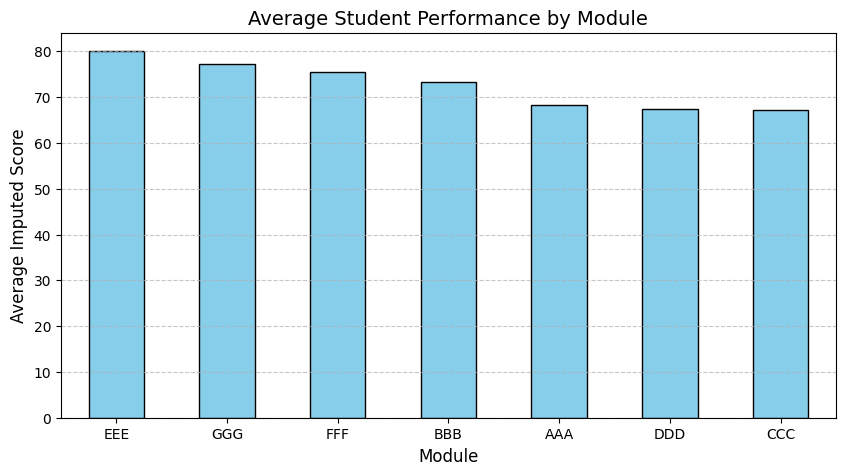

In [ ]:
import matplotlib.pyplot as plt

# Compute mean average per module
module_perf = (
    studentInfo.groupby('code_module')['avg_score_imputed']
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(10, 5))
module_perf.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Student Performance by Module', fontsize=14)
plt.ylabel('Average Imputed Score', fontsize=12)
plt.xlabel('Module', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


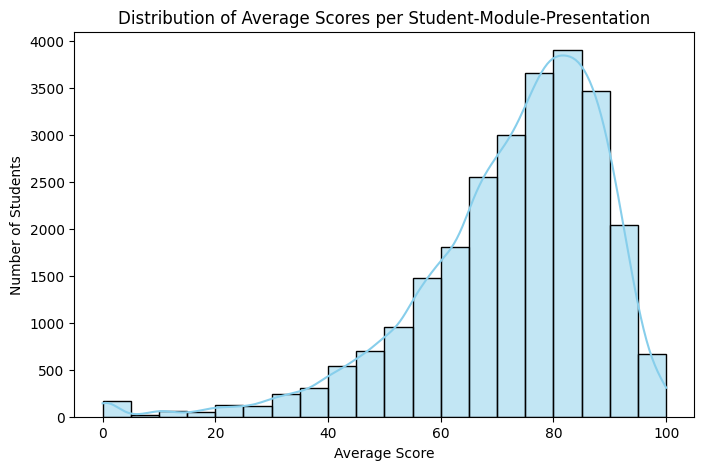

Number of rows where average score is above 100: 0


In [ ]:
# Use the already imputed average score from studentInfo for EDA
avg_scores_for_eda = studentInfo[['id_student', 'code_module', 'code_presentation', 'avg_score_imputed']].copy()

# Plot the distribution of average scores
plt.figure(figsize=(8,5))
sns.histplot(avg_scores_for_eda['avg_score_imputed'], bins=20, kde=True, color='skyblue')
plt.xlabel('Average Score')
plt.ylabel('Number of Students')
plt.title('Distribution of Average Scores per Student-Module-Presentation')
plt.show()

# Check if there is any average score above 100
score_above_100 = (avg_scores_for_eda['avg_score_imputed'] > 100).sum()
print(f"Number of rows where average score is above 100: {score_above_100}")


###**Method for computing student  engagement in MOOC**

In [ ]:
vle = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/vle.csv")
vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [ ]:
# Calculate student engagement with course materials
# Merge studentVle with vle by id_site, code_module, code_presentation
vle = pd.read_csv("/content/drive/MyDrive/Ds620Final/data/vle.csv")

vle_merged = studentVle.merge(
    vle,
    on=['id_site', 'code_module', 'code_presentation'],
    how='left'
)

# Preview the merged dataset
vle_merged.info()

# Check the number of unmatched records
unmatched_vle = vle[~vle['id_site'].isin(studentVle['id_site'])]
print(f"Number of unmatched records from vle: {unmatched_vle.shape[0]}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   code_module        object 
 1   code_presentation  object 
 2   id_student         int64  
 3   id_site            int64  
 4   date               int64  
 5   sum_click          int64  
 6   activity_type      object 
 7   week_from          float64
 8   week_to            float64
dtypes: float64(2), int64(4), object(3)
memory usage: 731.6+ MB
Number of unmatched records from vle: 96


96 of records in vle has no match in student Vle by id_site. The reason could be that no students interact with these course materials.The unmatched records do not affect our analysis because we are only concerned with the course materials student interacted with.

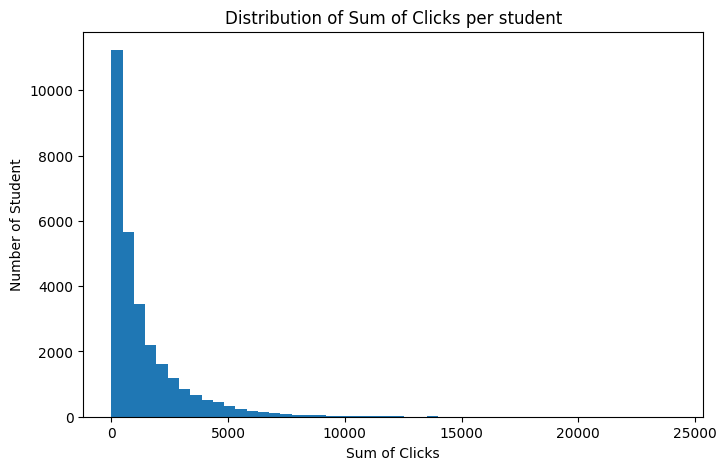

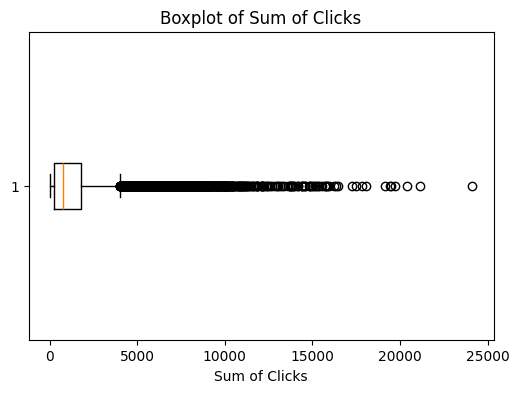

count    29228.000000
mean      1355.039654
std       1733.546045
min          1.000000
25%        260.750000
50%        739.500000
75%       1770.000000
max      24139.000000
Name: sum_click, dtype: float64


In [ ]:
# Calculate the metrics of student engagement with course materials
# Calculate each student's total clicks on all materials in a course

sum_click = (
    vle_merged.groupby(
        ['id_student', 'code_module', 'code_presentation'], as_index=False
    )['sum_click']
    .sum()
)

# Check the result by ploting sum_click and print out describe

plt.figure(figsize=(8,5))
plt.hist(sum_click['sum_click'], bins=50)
plt.xlabel('Sum of Clicks')
plt.ylabel('Number of Student')
plt.title('Distribution of Sum of Clicks per student')
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(sum_click['sum_click'], vert=False)
plt.xlabel('Sum of Clicks')
plt.title('Boxplot of Sum of Clicks')
plt.show()

print(sum_click['sum_click'].describe())


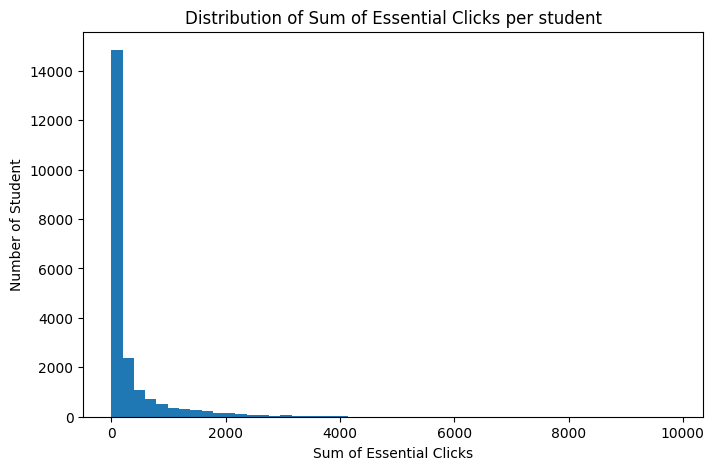

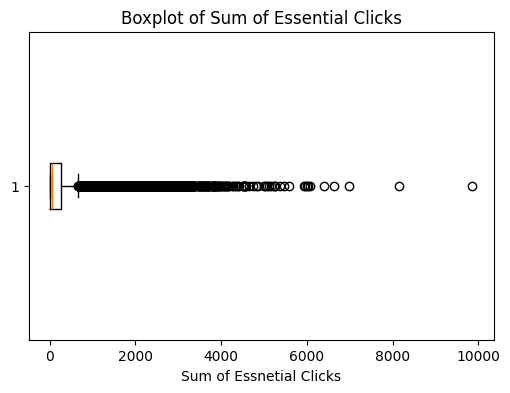

count    21470.000000
mean       300.340848
std        591.519115
min          1.000000
25%          9.000000
50%         62.000000
75%        274.000000
max       9862.000000
Name: essential_clicks, dtype: float64


In [ ]:
# Calculate each student's total clicks on essential course materials.
# Essential course materials are materials available in a set duration of time.
# They are id_site with value in week_from or week_to.
vle_essential = vle_merged[
    vle_merged['week_from'].notna() | vle_merged['week_to'].notna()
]

essential_clicks = vle_essential.groupby(
    ['id_student', 'code_module', 'code_presentation'], as_index=False
)['sum_click'].sum().rename(columns={'sum_click': 'essential_clicks'})

# Check the result by ploting essential_clicks and print out describe
plt.figure(figsize=(8,5))
plt.hist(essential_clicks['essential_clicks'], bins=50)
plt.xlabel('Sum of Essential Clicks')
plt.ylabel('Number of Student')
plt.title('Distribution of Sum of Essential Clicks per student')
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(essential_clicks['essential_clicks'], vert=False)
plt.xlabel('Sum of Essnetial Clicks')
plt.title('Boxplot of Sum of Essential Clicks')
plt.show()

print(essential_clicks['essential_clicks'].describe())

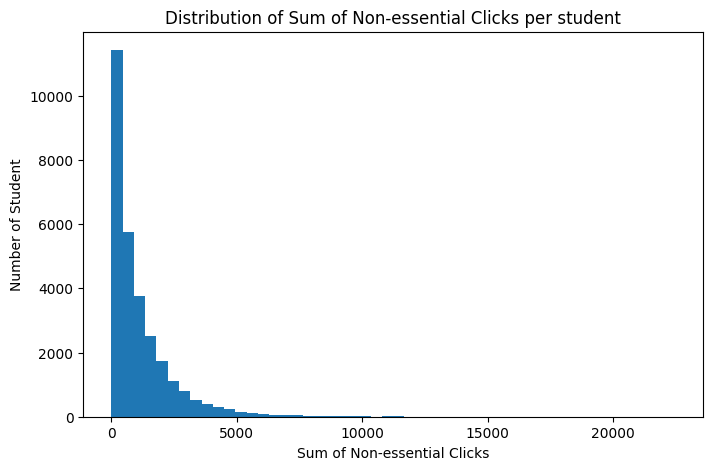

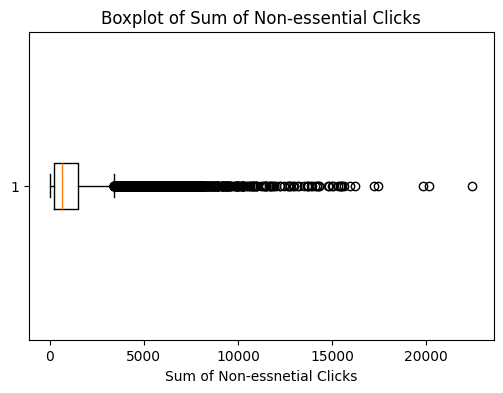

count    29226.000000
mean      1134.496031
std       1433.703734
min          1.000000
25%        234.000000
50%        672.000000
75%       1503.000000
max      22456.000000
Name: non_essential_clicks, dtype: float64


In [ ]:
# Calculate each student's total clicks on non-essential materials in a course
vle_non_essential = vle_merged[
    vle_merged['week_from'].isna() | vle_merged['week_to'].isna()
]

non_essential_clicks = vle_non_essential.groupby(
    ['id_student', 'code_module', 'code_presentation'], as_index=False
)['sum_click'].sum().rename(columns={'sum_click': 'non_essential_clicks'})

# Check the result by ploting non_essential_clicks and print out describe
plt.figure(figsize=(8,5))
plt.hist(non_essential_clicks['non_essential_clicks'], bins=50)
plt.xlabel('Sum of Non-essential Clicks')
plt.ylabel('Number of Student')
plt.title('Distribution of Sum of Non-essential Clicks per student')
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(non_essential_clicks['non_essential_clicks'], vert=False)
plt.xlabel('Sum of Non-essnetial Clicks')
plt.title('Boxplot of Sum of Non-essential Clicks')
plt.show()

print(non_essential_clicks['non_essential_clicks'].describe())


The histograms of students' total clicks, essential clicks, and non-essential clicks are all right-skewed. The max is extremely larger than the 75th percentile. This result shows that most students have low to moderate clicks, while a few are very active. They create a long tail to the right.

To compress range for regression, and stablize variance so that large extreme values do not dominate statistical analysis, we decided to apply a log transformation to all the three clicks data, before joining them into the studentInfo table.






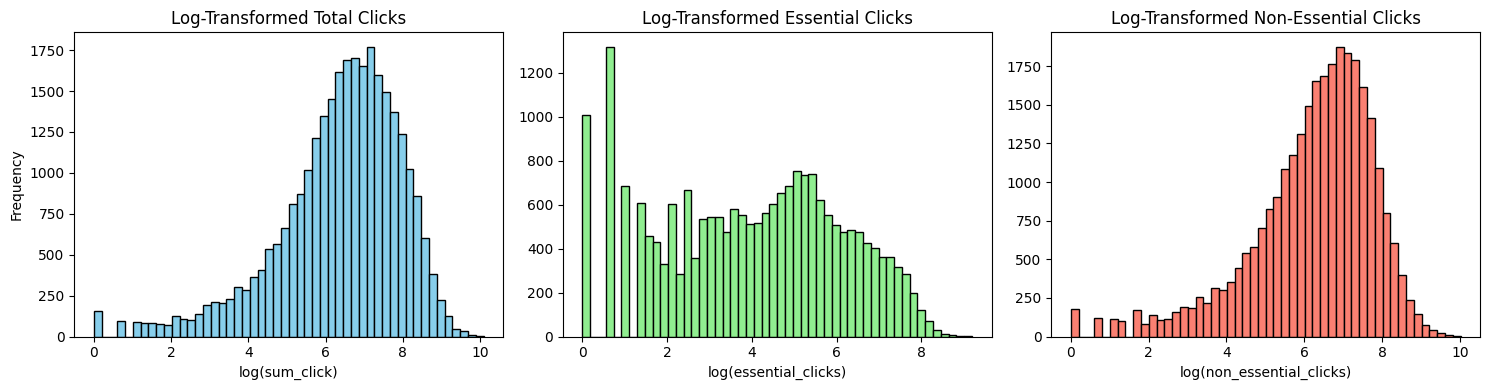

In [ ]:
# Perform log transformation on total clicks, essential clicks and non-essential clicks
sum_click['sum_click_log'] = np.log(sum_click['sum_click'])
essential_clicks['essential_clicks_log'] = np.log(essential_clicks['essential_clicks'])
non_essential_clicks['non_essential_clicks_log'] = np.log(non_essential_clicks['non_essential_clicks'])

# plot the histogram of total clicks, essential clicks and non-essential clicks after log transformation
plt.figure(figsize=(15, 4))

# Total clicks
plt.subplot(1, 3, 1)
plt.hist(sum_click['sum_click_log'], bins=50, color='skyblue', edgecolor='black')
plt.title('Log-Transformed Total Clicks')
plt.xlabel('log(sum_click)')
plt.ylabel('Frequency')

# Essential clicks
plt.subplot(1, 3, 2)
plt.hist(essential_clicks['essential_clicks_log'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Log-Transformed Essential Clicks')
plt.xlabel('log(essential_clicks)')

# Non-essential clicks
plt.subplot(1, 3, 3)
plt.hist(non_essential_clicks['non_essential_clicks_log'], bins=50, color='salmon', edgecolor='black')
plt.title('Log-Transformed Non-Essential Clicks')
plt.xlabel('log(non_essential_clicks)')

plt.tight_layout()
plt.show()

In [ ]:
# Merge log transformed total clicks, essential clicks and non-essential clicks into studentInfo dataframe
# Check if there is mismatch between the three tables and studentInfo

# Function to check unmatched rows in a click table
def check_unmatched(student_df, click_df, click_col_name):
    merged = student_df.merge(
        click_df[['id_student', 'code_module', 'code_presentation', click_col_name]],
        on=['id_student', 'code_module', 'code_presentation'],
        how='right',   # keep all rows from click_df
        indicator=True
    )
    unmatched_count = merged[merged['_merge'] == 'right_only'].shape[0]
    print(f"Rows in {click_col_name} not matched in studentInfo: {unmatched_count}")

# Check unmatched rows
check_unmatched(studentInfo, sum_click, 'sum_click_log')
check_unmatched(studentInfo, essential_clicks, 'essential_clicks_log')
check_unmatched(studentInfo, non_essential_clicks, 'non_essential_clicks_log')

# Perform merges
studentInfo = studentInfo.merge(
    sum_click[['id_student', 'code_module', 'code_presentation', 'sum_click_log']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

studentInfo = studentInfo.merge(
    essential_clicks[['id_student', 'code_module', 'code_presentation', 'essential_clicks_log']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

studentInfo = studentInfo.merge(
    non_essential_clicks[['id_student', 'code_module', 'code_presentation', 'non_essential_clicks_log']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)


Rows in sum_click_log not matched in studentInfo: 0
Rows in essential_clicks_log not matched in studentInfo: 0
Rows in non_essential_clicks_log not matched in studentInfo: 0


In [ ]:
# Call data_profiling function to check the studentInfo dataframe
data_profiling({"studentInfo":studentInfo})

Table Name: studentInfo 



,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score_observed,avg_score_imputed,count_obs,total_assessments,all_scores_missing,sum_click_log,essential_clicks_log,non_essential_clicks_log
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,82.0,5.0,5.0,False,6.839476,3.637586,6.797940
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,66.4,5.0,5.0,False,7.268920,4.127134,7.224753
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN,NaN,NaN,5.638355,3.332205,5.533389
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,76.0,5.0,5.0,False,7.676937,3.931826,7.653020
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,54.4,5.0,5.0,False,6.941190,4.927254,6.797940




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               32593 non-null  object 
 1   code_presentation         32593 non-null  object 
 2   id_student                32593 non-null  int64  
 3   gender                    32593 non-null  object 
 4   region                    32593 non-null  object 
 5   highest_education         32593 non-null  object 
 6   imd_band                  31482 non-null  object 
 7   age_band                  32593 non-null  object 
 8   num_of_prev_attempts      32593 non-null  int64  
 9   studied_credits           32593 non-null  int64  
 10  disability                32593 non-null  object 
 11  final_result              32593 non-null  object 
 12  avg_score_observed        25820 non-null  float64
 13  avg_score_imputed         25843 non-null  float64
 14  coun

###**Encoding Qualitative Variables**
Based on the output, the following steps of preprocessing are needed:

**1) Handle missing socio-economic information (imd_band).**
 The missing rate for this variable is relatively small, around 3%, and because it is a categorical variable, attempting to impute values would be unreliable. Therefore, we choose to remove these few records from the dataset.

**2)Handle missing values in average scores and clicks related columns.**
  The avg_score, num_assessments, num_missing, sum_click_log, essential_click_log, non_essential_click log columns exhibit higher missing rates, ranging from 10% to 34%. The main reason for these missing values is that studentInfo contains all students enrolled in the course, including those who deregistered. Since deregistered students are not relevant for analyzing course performance, we will remove them from the dataset.

  **3)Recode norminal and ordinal categorical variables.** Gender and region variables are norminal variables, highest_education, imd_band, age_band are ordinal variables. We recode norminal variables using one-hot encoding, turning each category into a separate binary column. And we recode ordinal variables into numerical values by their inherent order.

In [ ]:
# drop imd_band with missing values and validate
studentInfo = studentInfo.dropna(subset=['imd_band'])
print(f"Num of records with missing value in imd_band: {studentInfo['imd_band'].isna().sum()}")


Num of records with missing value in imd_band: 0


In [ ]:
# drop students who deregistered from courses
# deregistered students have value "Withdrawn" in final_result
print(studentInfo['final_result'].value_counts(normalize=True) * 100)

# keep studentInfo df because it is useful for descriptive statistical analysis
# create a new df studentInfo_registered to store students who did not withdraw from course
studentInfo_registered = studentInfo[studentInfo['final_result'] != 'Withdrawn']

# Call data_profiling function to check the studentInfo_registered dataframe
data_profiling({"studentInfo_registered":studentInfo_registered})


final_result
Pass           37.577028
Withdrawn      31.510069
Fail           21.939521
Distinction     8.973382
Name: proportion, dtype: float64
Table Name: studentInfo_registered 



,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score_observed,avg_score_imputed,count_obs,total_assessments,all_scores_missing,sum_click_log,essential_clicks_log,non_essential_clicks_log
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,82.0,5.0,5.0,False,6.839476,3.637586,6.797940
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,66.4,5.0,5.0,False,7.268920,4.127134,7.224753
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,76.0,5.0,5.0,False,7.676937,3.931826,7.653020
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,54.4,5.0,5.0,False,6.941190,4.927254,6.797940
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,68.0,68.0,5.0,5.0,False,7.801800,4.510860,7.763871




<class 'pandas.core.frame.DataFrame'>
Index: 21562 entries, 0 to 32592
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               21562 non-null  object 
 1   code_presentation         21562 non-null  object 
 2   id_student                21562 non-null  int64  
 3   gender                    21562 non-null  object 
 4   region                    21562 non-null  object 
 5   highest_education         21562 non-null  object 
 6   imd_band                  21562 non-null  object 
 7   age_band                  21562 non-null  object 
 8   num_of_prev_attempts      21562 non-null  int64  
 9   studied_credits           21562 non-null  int64  
 10  disability                21562 non-null  object 
 11  final_result              21562 non-null  object 
 12  avg_score_observed        20289 non-null  float64
 13  avg_score_imputed         20292 non-null  float64
 14  count_obs

After taking out deregistered student, essential_clicks_log still has 25% of missing value. It indicates that this variable is not a good variable to measure student performance in MOOC. We will drop it and the non_essential_clicks_log(less comprehensive than sum_click_log), and preserve only the sum_click_log as the metric for student engagement in MOOC.
Missing value in avg_score_imputed and sum_click_log are likely results of students who stayed registered in MOOC but never attend the class or complete any assignments. We will fill the missing values in both columns with 0, and check if these students all get a 'Fail' in the final_result.

In [ ]:
# Drop essential_clicks_log and non_essential_clicks_log
studentInfo_registered = studentInfo_registered.drop(columns=['essential_clicks_log'])
studentInfo_registered = studentInfo_registered.drop(columns=['non_essential_clicks_log'])

# Fill in missing values
studentInfo_registered['sum_click_log'] = studentInfo_registered['sum_click_log'].fillna(0)
studentInfo_registered['avg_score_imputed'] = studentInfo_registered['avg_score_imputed'].fillna(0)

In [ ]:
# check if students with 0 in sum_click_log or avg_score_imputed has Fail in final_result
studentInfo_registered[
    (studentInfo_registered['sum_click_log'] == 0) | (studentInfo_registered['avg_score_imputed'] == 0)
]['final_result'].value_counts()


,count
final_result,
Fail,1321
Pass,5


In [ ]:
# Inconsistency is detected.
# 5 students who passed the course have 0 in either final score or sum_click_log
# Remove these 5 records from studentInfo_registered
studentInfo_registered = studentInfo_registered[
    ~(
        ((studentInfo_registered['avg_score_imputed'] == 0) |
         (studentInfo_registered['sum_click_log'] == 0)) &
        (studentInfo_registered['final_result'] == 'Pass')
    )
]


In [ ]:
# check the consistency of data again
studentInfo_registered[
    (studentInfo_registered['sum_click_log'] == 0) | (studentInfo_registered['avg_score_imputed'] == 0)
]['final_result'].value_counts()


,count
final_result,
Fail,1321


In [ ]:
# call data_profiling function to check on the studentInfo_registered dataframe
data_profiling({"studentInfo_registered":studentInfo_registered})

Table Name: studentInfo_registered 



,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score_observed,avg_score_imputed,count_obs,total_assessments,all_scores_missing,sum_click_log
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,82.0,5.0,5.0,False,6.839476
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,66.4,5.0,5.0,False,7.268920
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,76.0,5.0,5.0,False,7.676937
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,54.4,5.0,5.0,False,6.941190
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,68.0,68.0,5.0,5.0,False,7.801800




<class 'pandas.core.frame.DataFrame'>
Index: 21557 entries, 0 to 32592
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           21557 non-null  object 
 1   code_presentation     21557 non-null  object 
 2   id_student            21557 non-null  int64  
 3   gender                21557 non-null  object 
 4   region                21557 non-null  object 
 5   highest_education     21557 non-null  object 
 6   imd_band              21557 non-null  object 
 7   age_band              21557 non-null  object 
 8   num_of_prev_attempts  21557 non-null  int64  
 9   studied_credits       21557 non-null  int64  
 10  disability            21557 non-null  object 
 11  final_result          21557 non-null  object 
 12  avg_score_observed    20287 non-null  float64
 13  avg_score_imputed     21557 non-null  float64
 14  count_obs             20290 non-null  float64
 15  total_assessments     

Based on the output, we confirm that all the variables that are going to be used for modeling have no missing values. Now we move on the encode qualitative variables.

In [ ]:
# check the values in categorical variables
categorical_col = ['gender','region','highest_education','imd_band',
                   'age_band','disability','final_result']

for col in categorical_col:
    print(f"Column: {col}")
    print("Unique values:", studentInfo_registered[col].unique())
    print("Counts:\n", studentInfo_registered[col].value_counts())
    print("-" * 40)


Column: gender
Unique values: ['M' 'F']
Counts:
 gender
M    11566
F     9991
Name: count, dtype: int64
----------------------------------------
Column: region
Unique values: ['East Anglian Region' 'Scotland' 'South East Region'
 'West Midlands Region' 'Wales' 'North Western Region' 'South Region'
 'South West Region' 'East Midlands Region' 'Yorkshire Region'
 'London Region' 'North Region' 'Ireland']
Counts:
 region
Scotland                2531
East Anglian Region     2332
South Region            2122
London Region           2105
North Western Region    1868
South West Region       1674
West Midlands Region    1636
Wales                   1562
East Midlands Region    1543
South East Region       1462
Yorkshire Region        1348
Ireland                  695
North Region             679
Name: count, dtype: int64
----------------------------------------
Column: highest_education
Unique values: ['HE Qualification' 'A Level or Equivalent' 'Lower Than A Level'
 'Post Graduate Qualification

In [ ]:
# gender, region and disability are nominal variables
# highest_education, imd_band, age_band, final_result are cardinal variables

# encode nominal variables first
# Apply one-hot encoding to nominal variables
studentInfo_encoded = pd.get_dummies(
    studentInfo_registered,
    columns=['gender', 'region', 'disability'],  # nominal features
    drop_first=True   #set drop_first to be True to drop one dummy column for each dummy variable to avoid perfect multicollinearity that would produce error in regressional analysis.
)

# Verify encoding
print("\n One-hot encoding complete.")
print("Encoded dataset shape:", studentInfo_encoded.shape)

print(studentInfo_encoded.columns.tolist())

studentInfo_encoded.head(5)



 One-hot encoding complete.
Encoded dataset shape: (21557, 29)
['code_module', 'code_presentation', 'id_student', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'final_result', 'avg_score_observed', 'avg_score_imputed', 'count_obs', 'total_assessments', 'all_scores_missing', 'sum_click_log', 'gender_M', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'disability_Y']


,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,final_result,avg_score_observed,...,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,disability_Y
0,AAA,2013J,11391,HE Qualification,90-100%,55<=,0,240,Pass,82.0,...,False,False,False,False,False,False,False,False,False,False
1,AAA,2013J,28400,HE Qualification,20-30%,35-55,0,60,Pass,66.4,...,False,False,True,False,False,False,False,False,False,False
3,AAA,2013J,31604,A Level or Equivalent,50-60%,35-55,0,60,Pass,76.0,...,False,False,False,True,False,False,False,False,False,False
4,AAA,2013J,32885,Lower Than A Level,50-60%,0-35,0,60,Pass,54.4,...,False,False,False,False,False,False,False,True,False,False
5,AAA,2013J,38053,A Level or Equivalent,80-90%,35-55,0,60,Pass,68.0,...,False,False,False,False,False,False,True,False,False,False


**Encoding Cardinal Variables**

We finished encoding ordinal features (highest_education, imd_band, age_band) and binary feature (all_scores_missing), and moved on the encode cardinal variables (age_band, imd_order, and highest_education).


In [ ]:
# Define ordinal mappings
edu_order = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}

imd_order = {
    '0-10%': 0,
    '10-20%': 1,
    '20-30%': 2,
    '20-Oct': 2,
    '30-40%': 3,
    '40-50%': 4,
    '50-60%': 5,
    '60-70%': 6,
    '70-80%': 7,
    '80-90%': 8,
    '90-100%': 9
}

age_order = {
    '0-35': 0,
    '35-55': 1,
    '55<=': 2
}

# Apply encodings (only if columns exist)
for col, mapping in {
    'highest_education': edu_order,
    'imd_band': imd_order,
    'age_band': age_order
}.items():
    if col in studentInfo_encoded.columns:
        studentInfo_encoded[col] = studentInfo_encoded[col].map(mapping)


print("Encoding of cardinal variables complete.")
print("Dataset shape after all recoding:", studentInfo_encoded.shape)
studentInfo_encoded.head()


Encoding of cardinal variables complete.
Dataset shape after all recoding: (21557, 29)


,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,final_result,avg_score_observed,...,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,disability_Y
0,AAA,2013J,11391,3,9,2,0,240,Pass,82.0,...,False,False,False,False,False,False,False,False,False,False
1,AAA,2013J,28400,3,2,1,0,60,Pass,66.4,...,False,False,True,False,False,False,False,False,False,False
3,AAA,2013J,31604,2,5,1,0,60,Pass,76.0,...,False,False,False,True,False,False,False,False,False,False
4,AAA,2013J,32885,1,5,0,0,60,Pass,54.4,...,False,False,False,False,False,False,False,True,False,False
5,AAA,2013J,38053,2,8,1,0,60,Pass,68.0,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
data_profiling({"studentInfo_encoded":studentInfo_encoded})

Table Name: studentInfo_encoded 



,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,final_result,avg_score_observed,...,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,disability_Y
0,AAA,2013J,11391,3,9,2,0,240,Pass,82.0,...,False,False,False,False,False,False,False,False,False,False
1,AAA,2013J,28400,3,2,1,0,60,Pass,66.4,...,False,False,True,False,False,False,False,False,False,False
3,AAA,2013J,31604,2,5,1,0,60,Pass,76.0,...,False,False,False,True,False,False,False,False,False,False
4,AAA,2013J,32885,1,5,0,0,60,Pass,54.4,...,False,False,False,False,False,False,False,True,False,False
5,AAA,2013J,38053,2,8,1,0,60,Pass,68.0,...,False,False,False,False,False,False,True,False,False,False




<class 'pandas.core.frame.DataFrame'>
Index: 21557 entries, 0 to 32592
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   code_module                  21557 non-null  object 
 1   code_presentation            21557 non-null  object 
 2   id_student                   21557 non-null  int64  
 3   highest_education            21557 non-null  int64  
 4   imd_band                     21557 non-null  int64  
 5   age_band                     21557 non-null  int64  
 6   num_of_prev_attempts         21557 non-null  int64  
 7   studied_credits              21557 non-null  int64  
 8   final_result                 21557 non-null  object 
 9   avg_score_observed           20287 non-null  float64
 10  avg_score_imputed            21557 non-null  float64
 11  count_obs                    20290 non-null  float64
 12  total_assessments            20290 non-null  float64
 13  all_scores_missing 

### **Rescaling Data**

The output above confirms that all encoding have been implemented successfully. Now we move on the check the range of values in variables, and consider rescaling some variables for machine learning algorithms.

In [ ]:
# num_of_prev_attemps and studied_credits are numerical variables
# check and compare them with other numerical variables to see if they need to be rescaled
print(studentInfo_registered['num_of_prev_attempts'].describe())
print('\n',studentInfo_registered['studied_credits'].describe())
print('\n',studentInfo_registered['sum_click_log'].describe())
print('\n',studentInfo_registered['avg_score_imputed'].describe())

count    21557.000000
mean         0.154242
std          0.466752
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
Name: num_of_prev_attempts, dtype: float64

 count    21557.000000
mean        74.407153
std         36.872368
min         30.000000
25%         60.000000
50%         60.000000
75%         90.000000
max        630.000000
Name: studied_credits, dtype: float64

 count    21557.000000
mean         6.608602
std          1.625478
min          0.000000
25%          5.981414
50%          6.877296
75%          7.664816
max         10.091584
Name: sum_click_log, dtype: float64

 count    21557.000000
mean        70.113487
std         22.420366
min          0.000000
25%         63.916667
50%         76.083333
75%         84.555556
max        100.000000
Name: avg_score_imputed, dtype: float64


In [ ]:
# use min-max scaling to rescale all variables to range (0,1)
import sklearn
from sklearn.preprocessing import MinMaxScaler

# 1. Make a copy of the original dataframe
studentInfo_scaled = studentInfo_encoded.copy()

# 2. Select all columns except final_result
cols_to_scale = studentInfo_scaled.columns.drop(['final_result','code_module','code_presentation'])

# 3. Create the MinMax scaler
scaler = MinMaxScaler()

# 4. Fit and transform ONLY the selected columns
studentInfo_scaled[cols_to_scale] = scaler.fit_transform(studentInfo_scaled[cols_to_scale])


# check the rescaled dataframe
data_profiling({"studentInfo_scaled":studentInfo_scaled})

Table Name: studentInfo_scaled 



,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,final_result,avg_score_observed,...,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,disability_Y
0,AAA,2013J,0.001803,0.75,1.000000,1.0,0.0,0.35,Pass,0.820,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AAA,2013J,0.008094,0.75,0.222222,0.5,0.0,0.05,Pass,0.664,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AAA,2013J,0.009279,0.50,0.555556,0.5,0.0,0.05,Pass,0.760,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AAA,2013J,0.009752,0.25,0.555556,0.0,0.0,0.05,Pass,0.544,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,AAA,2013J,0.011664,0.50,0.888889,0.5,0.0,0.05,Pass,0.680,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0




<class 'pandas.core.frame.DataFrame'>
Index: 21557 entries, 0 to 32592
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   code_module                  21557 non-null  object 
 1   code_presentation            21557 non-null  object 
 2   id_student                   21557 non-null  float64
 3   highest_education            21557 non-null  float64
 4   imd_band                     21557 non-null  float64
 5   age_band                     21557 non-null  float64
 6   num_of_prev_attempts         21557 non-null  float64
 7   studied_credits              21557 non-null  float64
 8   final_result                 21557 non-null  object 
 9   avg_score_observed           20287 non-null  float64
 10  avg_score_imputed            21557 non-null  float64
 11  count_obs                    20290 non-null  float64
 12  total_assessments            20290 non-null  float64
 13  all_scores_missing 

 The dataset is now entirely numeric, and rescaled. All variables that will be used for multivariat regression have no missing values. We create a dataset for regression by dropping other variables not needed for the task.



In [ ]:
studentInfo_scaled = studentInfo_scaled.drop(columns=['avg_score_observed','count_obs','total_assessments','all_scores_missing'])
data_profiling({'studentInfo_scaled':studentInfo_scaled})

Table Name: studentInfo_scaled 



,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,final_result,avg_score_imputed,...,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,disability_Y
0,AAA,2013J,0.001803,0.75,1.000000,1.0,0.0,0.35,Pass,0.820,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AAA,2013J,0.008094,0.75,0.222222,0.5,0.0,0.05,Pass,0.664,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AAA,2013J,0.009279,0.50,0.555556,0.5,0.0,0.05,Pass,0.760,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AAA,2013J,0.009752,0.25,0.555556,0.0,0.0,0.05,Pass,0.544,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,AAA,2013J,0.011664,0.50,0.888889,0.5,0.0,0.05,Pass,0.680,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0




<class 'pandas.core.frame.DataFrame'>
Index: 21557 entries, 0 to 32592
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   code_module                  21557 non-null  object 
 1   code_presentation            21557 non-null  object 
 2   id_student                   21557 non-null  float64
 3   highest_education            21557 non-null  float64
 4   imd_band                     21557 non-null  float64
 5   age_band                     21557 non-null  float64
 6   num_of_prev_attempts         21557 non-null  float64
 7   studied_credits              21557 non-null  float64
 8   final_result                 21557 non-null  object 
 9   avg_score_imputed            21557 non-null  float64
 10  sum_click_log                21557 non-null  float64
 11  gender_M                     21557 non-null  float64
 12  region_East Midlands Region  21557 non-null  float64
 13  region_Ireland     

In [ ]:
studentInfo_scaled['final_result'].describe()

,final_result
count,21557
unique,3
top,Pass
freq,11825


### Preprocessing Complete
The output above validate that dataframe studentInfo_scaled is ready for maching learning algorithms.

#**Exploratory Data Analysis**
This section will explore the patterns of student performance in MOOC. We aim to produce presentation-ready visualizations, select features that will be used to train classifiers, and decide on a sampling strategy through the explorative data analysis.

The majority of analysis in this section is performed on the studentInfo dataframe, which is the dataframe that was not encoded, rescaled, and reduced (the dataframe includes withdrawn students). This is because it is easier to generate visuals of this dataframe. In the correlation analysis part, we use the dataframe ready for classifier training, the studentInfo_scaled.  


In [ ]:
studentInfo.info()


<class 'pandas.core.frame.DataFrame'>
Index: 31482 entries, 0 to 32592
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               31482 non-null  object 
 1   code_presentation         31482 non-null  object 
 2   id_student                31482 non-null  int64  
 3   gender                    31482 non-null  object 
 4   region                    31482 non-null  object 
 5   highest_education         31482 non-null  object 
 6   imd_band                  31482 non-null  object 
 7   age_band                  31482 non-null  object 
 8   num_of_prev_attempts      31482 non-null  int64  
 9   studied_credits           31482 non-null  int64  
 10  disability                31482 non-null  object 
 11  final_result              31482 non-null  object 
 12  avg_score_observed        24822 non-null  float64
 13  avg_score_imputed         24845 non-null  float64
 14  count_obs  

Overview of Dataset

We start by exploring the structure of each main dataset (studentInfo, studentAssessment, studentRegistration, and studentVLE) to understand the type and amount of data we have after cleaning

In [ ]:
# Check basic info of each dataset
print("---- studentInfo ----")
display(studentInfo.info())

print("\n---- studentAssessment ----")
display(studentAssessment.info())

print("\n---- studentRegistration ----")
display(studentRegistration.info())

print("\n---- studentVLE ----")
display(studentVle.info())

---- studentInfo ----
<class 'pandas.core.frame.DataFrame'>
Index: 31482 entries, 0 to 32592
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               31482 non-null  object 
 1   code_presentation         31482 non-null  object 
 2   id_student                31482 non-null  int64  
 3   gender                    31482 non-null  object 
 4   region                    31482 non-null  object 
 5   highest_education         31482 non-null  object 
 6   imd_band                  31482 non-null  object 
 7   age_band                  31482 non-null  object 
 8   num_of_prev_attempts      31482 non-null  int64  
 9   studied_credits           31482 non-null  int64  
 10  disability                31482 non-null  object 
 11  final_result              31482 non-null  object 
 12  avg_score_observed        24822 non-null  float64
 13  avg_score_imputed         24845 non-null  fl

None


---- studentAssessment ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_assessment      173912 non-null  int64  
 1   id_student         173912 non-null  int64  
 2   date_submitted     173912 non-null  int64  
 3   is_banked          173912 non-null  int64  
 4   score              173739 non-null  float64
 5   code_module        173912 non-null  object 
 6   code_presentation  173912 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 9.3+ MB


None


---- studentRegistration ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  object 
 1   code_presentation    32593 non-null  object 
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ MB


None


---- studentVLE ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB


None

This confirms if preprocessing was successful — ensuring there are no missing key variables and the data types are correct. It also gives a quick idea of how large each dataset is and what kind of information each one provides.

Summary Statistics

We compute key numerical summaries such as mean, median, standard deviation, and quartiles to understand student performance and engagement.

In [ ]:
# Summary statistics for student performance
performance_summary = studentInfo[['avg_score_imputed', 'final_result']].describe()
display(performance_summary)

,avg_score_imputed
count,24845.000000
mean,72.521019
std,16.548874
min,0.000000
25%,64.363636
50%,75.916667
75%,84.363636
max,100.000000


## Distribution of Final Results

Let's see how many students passed, failed, or withdrew from courses.

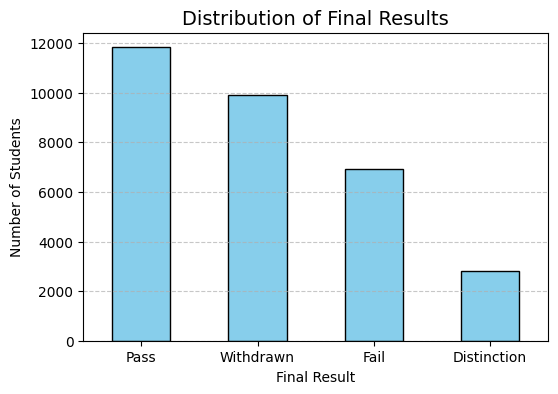

In [ ]:
import matplotlib.pyplot as plt

# Count of final results
result_counts = studentInfo['final_result'].value_counts()

# Plot the results
plt.figure(figsize=(6,4))
result_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Final Results', fontsize=14)
plt.xlabel('Final Result')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


This bar chart shows that over 50% of students either fail or withdrawn from MOOC. It conforms with the well-known pattern of student attrition in MOOCs, meaning a large proportion of enrolled learners either withdraw or fail to complete the course.

**Average Score Distribution**

We now visualize how students’ average scores are distributed.

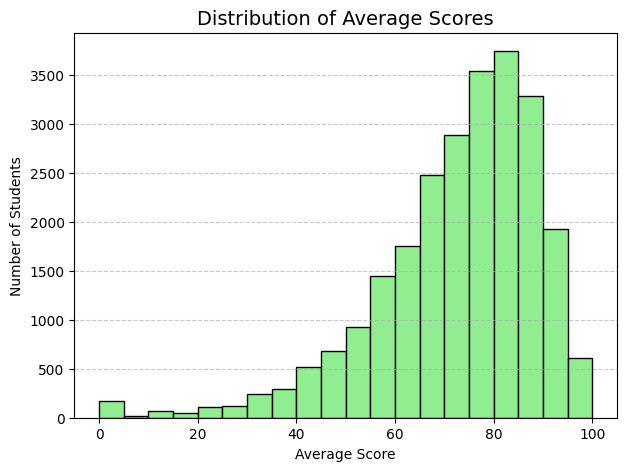

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(studentInfo['avg_score_imputed'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Average Scores', fontsize=14)
plt.xlabel('Average Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The histogram is left-skewed, meaning that most students who did not withdrawn performed well.



Now we move on to check how many students are enrolled in each course across different semesters. This will help us identify a sampling strategy.

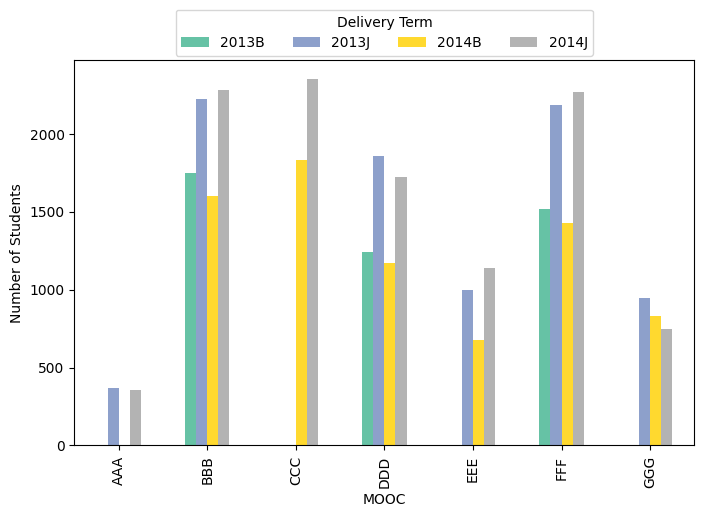

In [ ]:
studentInfo.groupby(['code_module', 'code_presentation']).size().unstack().plot(
    kind='bar',
    figsize=(8,5),
    stacked=False,  # set True for stacked bars
    colormap='Set2'
)

plt.ylabel('Number of Students')
plt.xlabel('MOOC')

# Move legend above the plot
plt.legend(title='Delivery Term', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)

plt.show()



## Sampling Strategy

Based on the output, we adopt a stratified sampling strategy to split the dataset into training and testing sets, using a combination of code_module and code_presentation as strata to ensure proportional representation of each course and semester.

## Course Performance by Demographical Factors

We explore the distribution of final result by age group, gender, socio-economic background, and region.

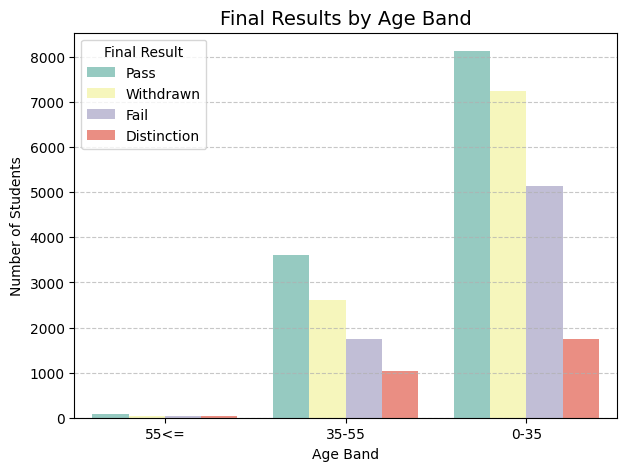

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='age_band', hue='final_result', data=studentInfo, palette='Set3')
plt.title('Final Results by Age Band', fontsize=14)
plt.xlabel('Age Band')
plt.ylabel('Number of Students')
plt.legend(title='Final Result')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


This plot shows that there is very few students above 55 in our dataset. And student between age 35-55 demonstrates a clearly higher ratio to get 'Distinction' as final result. This pattern is interesting. We can make an educated guess that people between 35-55 are matured adult who are better at self-discpline. They are also more economically stable than younger population, allowing them the ability to commit time into an MOOC (imaging an individual under 35, who has yet to have established career, juggling multiple jobs to make ends meet, hence can't commit as much time to an MOOC). Another reason might be, people between 35-55 are generally mid-career who look for breakthrough. They come to MOOC with clear goal to pick up new skills. Younger population, on the other hand, might not have a clear goal in mind when signing up for these classes. It makes them less committed and motivated in class.

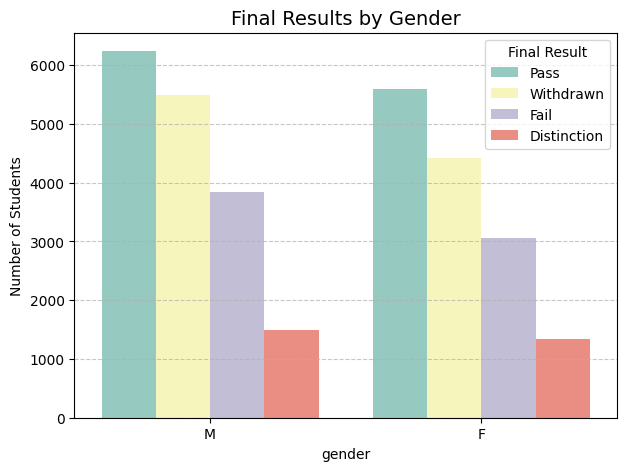

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='gender', hue='final_result', data=studentInfo, palette='Set3')
plt.title('Final Results by Gender', fontsize=14)
plt.xlabel('gender')
plt.ylabel('Number of Students')
plt.legend(title='Final Result')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


This plot shows that there are slightly more male students than female students in our data. In terms of their course performance, women shows a slightly higher ratio of getting a 'Distinction' as final result.

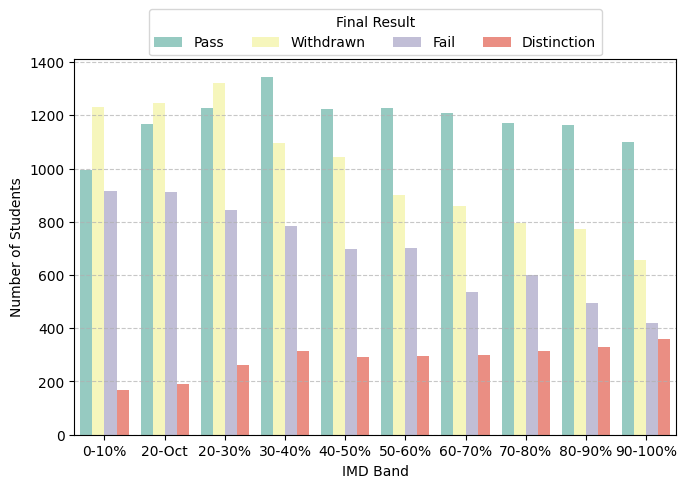

In [ ]:
imd_order = [
    "0-10%", "20-Oct", "20-30%", "30-40%", "40-50%",
    "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"
]

plt.figure(figsize=(7,5))
ax = sns.countplot(
    x='imd_band',
    hue='final_result',
    data=studentInfo,
    palette='Set3',
    order=imd_order
)

plt.xlabel('IMD Band')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Move legend above the plot
plt.legend(title='Final Result', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)

plt.tight_layout()
plt.show()


The IMD band refers to the Index of Multiple Deprivation, a commonly used socio-economic indicator in the UK. It measures area-level deprivation across multiple dimensions and classifies small geographic areas into “bands” or categories, with Band 1 representing the most deprived and Band 10 the least deprived. Note that "20-Oct" corresponds to 10–20%; this error was present in the original dataset but was corrected during our encoding process. Since the current analysis uses the dataset before encoding, the mislabeling is still visible.

The graph shows that students from less deprived areas tend to perform better in the MOOC, exhibiting a higher rate of distinctions and a lower rate of withdrawals.

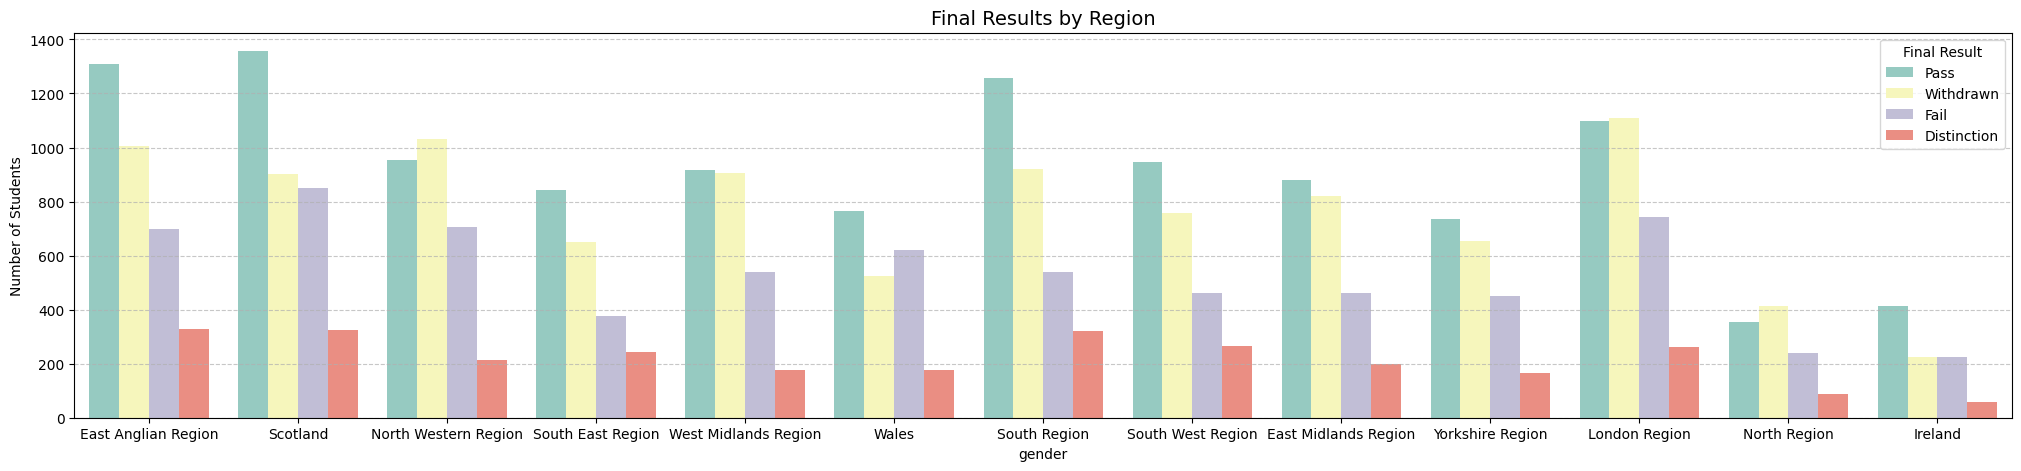

In [ ]:
plt.figure(figsize=(25,5))
sns.countplot(x='region', hue='final_result', data=studentInfo, palette='Set3')
plt.title('Final Results by Region', fontsize=14)
plt.xlabel('gender')
plt.ylabel('Number of Students')
plt.legend(title='Final Result')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We plotted regional disparities in learning performance. No noticeable pattern emerges, other than the predictable fact that fewer students come from less populated areas.

Initially, we considered using the region variable to incorporate socio-economic conditions into our model. However, since the IMD Band already captures place-based socio-economic status, we decided to drop the region variable from modeling to avoid multicollinearity (i.e. two variable measuring the same construct.)


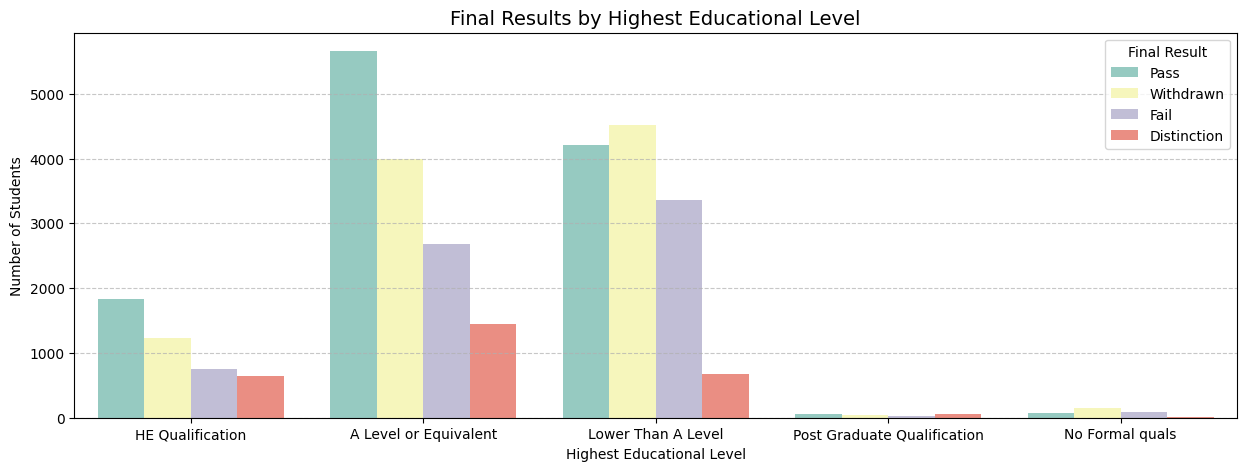

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='highest_education', hue='final_result', data=studentInfo, palette='Set3')
plt.title('Final Results by Highest Educational Level', fontsize=14)
plt.xlabel('Highest Educational Level')
plt.ylabel('Number of Students')
plt.legend(title='Final Result')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This plot reveals an interesting pattern: while there is only a tiny portion of students with post graduate qualifications, their rate to pass or receive 'Distinction' from class is significantly higher. They are also much less likely to withdraw from MOOC.

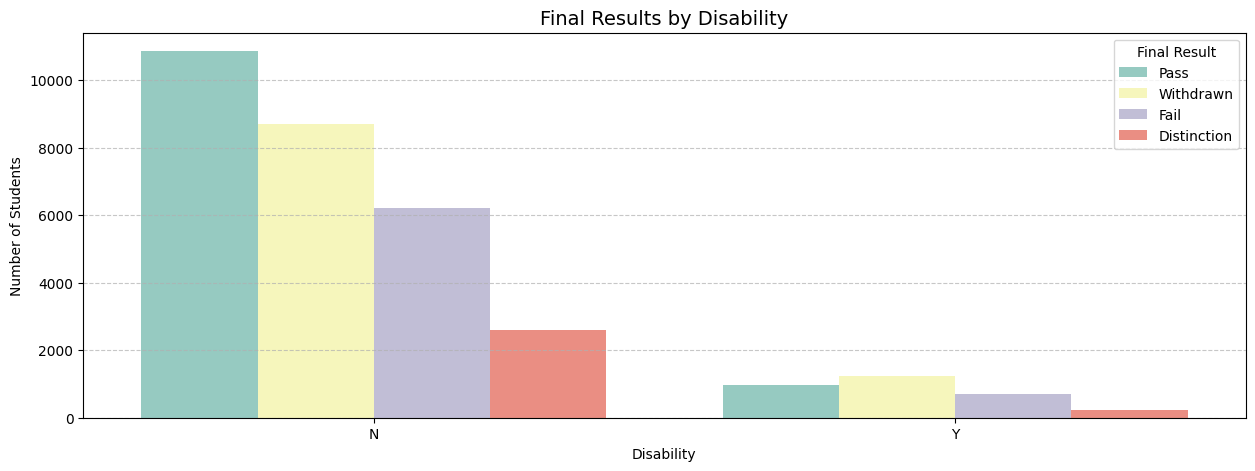

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='disability', hue='final_result', data=studentInfo, palette='Set3')
plt.title('Final Results by Disability', fontsize=14)
plt.xlabel('Disability')
plt.ylabel('Number of Students')
plt.legend(title='Final Result')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The plot shows that students with disability are only a faction of the total population. They are more likely to withdraw from MOOC than students without disability. But the number of student with disability is so small that we cannot be certain if this phenomenon is accidental occurance or a pattern that can be repeatitively observed.

## Course Performance by Engagement Level

We move on to check the distribution of final result across VLE clicks (student's total click on course materials) and average score (which we aggregated from other data).

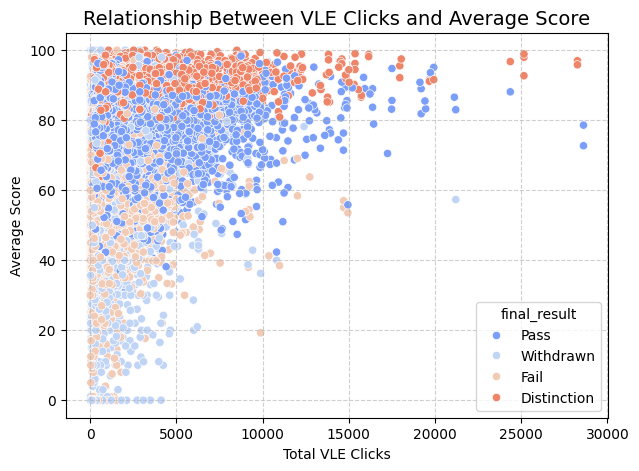

In [ ]:
# Merge average score with total VLE interactions
vle_summary = studentVle.groupby('id_student', as_index=False)['sum_click'].sum()
merged_df = studentInfo.merge(vle_summary, on='id_student', how='left')

# Scatter plot
plt.figure(figsize=(7,5))
sns.scatterplot(x='sum_click', y='avg_score_imputed', hue='final_result', data=merged_df, palette='coolwarm')
plt.title('Relationship Between VLE Clicks and Average Score', fontsize=14)
plt.xlabel('Total VLE Clicks')
plt.ylabel('Average Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This scatterplot reveals two trends:

1) Students with higher VLE clicks are better performed in class. However, there are students with low clicks but pass or obtain distinction from MOOC. This could be that such students have existing knowledge on the subject matter, and/or are strong learner (eg. good at taking note so they do not have to revisit content).

2) The aggregated average score is a strong indicator of final result. This is predicatble, since final letter grade of student is awarded according to the total score they received from a class. There are some data points when the average score is below 80 but the final result is distinction, or when the average score is below 60 but the student still pass. These inconsistencies might be a result of error in original dataset plus the way we calculate average score. But such inconsistencies are rare occurence.

3) What we come to as conclusion from this plot is, we need to drop average score from the list of features we use to train classifier. This is because average score will almost perfectly predict the outcome (final result). It will prevent the model from learning anything meaningful from other features (total clicks, gender, IMD_band, disability, education level, age group).

We have two more variables related to final result,the num_of_prev_attempts and studied_credits. Plot the distribution of final results by these two variables.        

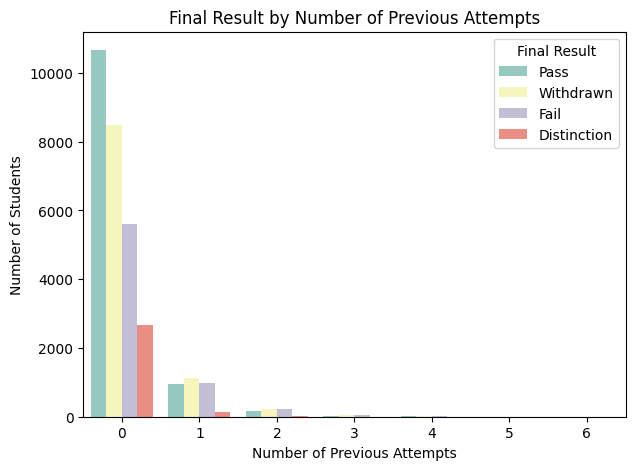

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='num_of_prev_attempts',
    hue='final_result',
    data=studentInfo,
    palette='Set3'
)
plt.title('Final Result by Number of Previous Attempts')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Number of Students')
plt.legend(title='Final Result')
plt.show()


/tmp/ipython-input-788514327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


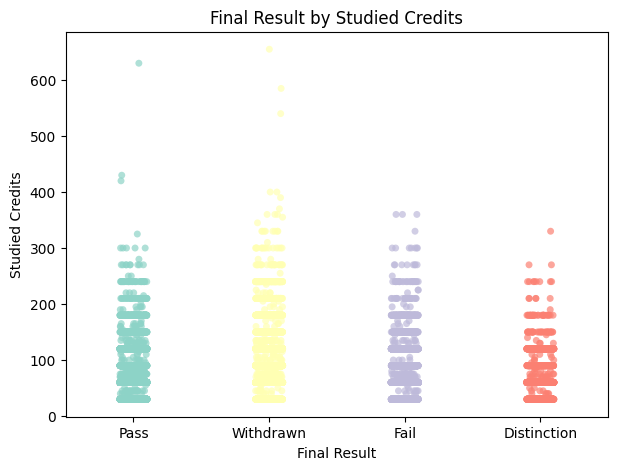

In [ ]:
plt.figure(figsize=(7,5))
sns.stripplot(
    x='final_result',
    y='studied_credits',
    data=studentInfo,
    jitter=True,          # adds horizontal noise to avoid overlapping points
    palette='Set3',
    alpha=0.7
)
plt.title('Final Result by Studied Credits')
plt.xlabel('Final Result')
plt.ylabel('Studied Credits')
plt.show()



From the above two graphs, we can only tell that the vast majority of students taking courses are on their first attempt. There is no noticeble pattern in terms of how final result change by number of previous attemps and studied credits.

##Correlation Analysis
Before training algorithms, we want to make sure that all features we selected are not strongly correlated. This is a preemptive measure to avoid multicollinearity. Here we will use the studentInfo_scaled dataframe because it is entirely numerical, hence ready for correlation analysis.

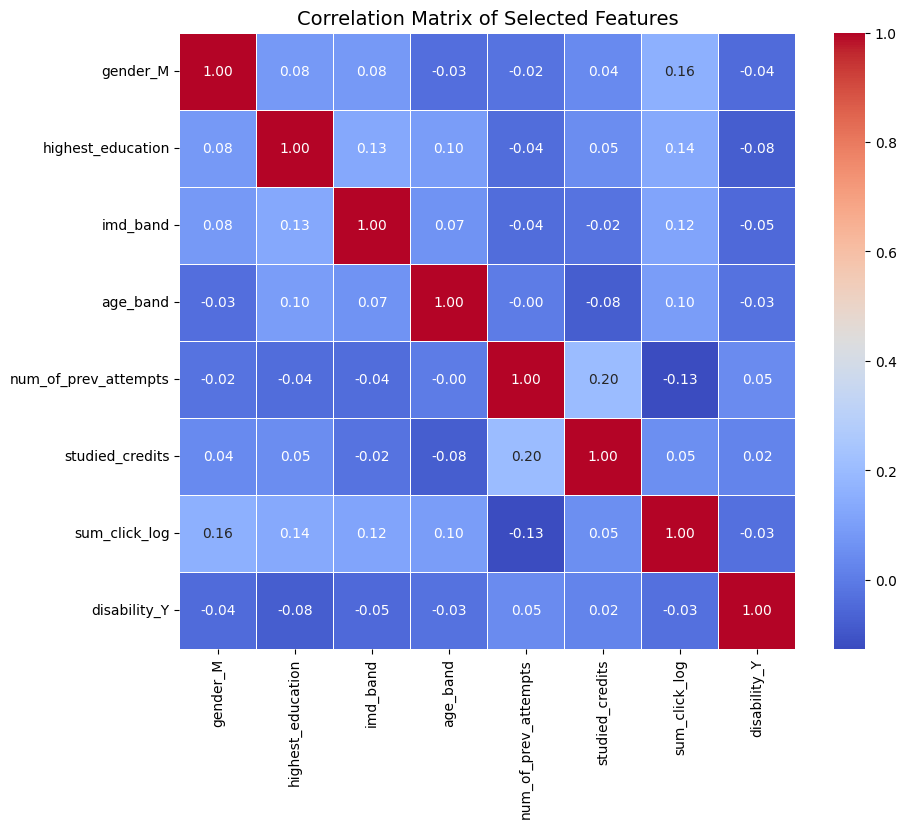

In [ ]:
features = [
    'gender_M',
    'highest_education',
    'imd_band',
    'age_band',
    'num_of_prev_attempts',
    'studied_credits',
    'sum_click_log',
    'disability_Y'
]

df_corr = studentInfo_encoded[features]

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix of Selected Features", fontsize=14)
plt.show()



The output confirms that there is no strong correlation between any of the features we selected to train models.



# Modeling and Testing

By far, we have had all feature candidates encoded numerically and rescaled to the range of [0,1]. We have also, through our explorative data analysis, selected features that we will use to train algorithms and provided justifications. Additionally, we have identified a stratefied sampling strategy based on the characteristics of our data. We are now ready to proceed to build and evaluate predictive models using different algorithms.


We will:
1. Recode our target variable, final_result. So far we keep it in original label for the ease of understanding.
2. Split the dataset into 60/40 using stratified sampling by both code_module and code_presentation.
3. Train classification models (Logistic Regression and Random Forest).
4. Evaluate model performance using accuracy, precision, recall, and F1-score metrics.

These operation will be performed on the dataframe we prepared for ML, studentInfo_scaled.

In [ ]:
data_profiling({"studentInfo_scaled":studentInfo_scaled})

Table Name: studentInfo_scaled 



,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,final_result,avg_score_imputed,...,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,disability_Y
0,AAA,2013J,0.001803,0.75,1.000000,1.0,0.0,0.35,Pass,0.820,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AAA,2013J,0.008094,0.75,0.222222,0.5,0.0,0.05,Pass,0.664,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AAA,2013J,0.009279,0.50,0.555556,0.5,0.0,0.05,Pass,0.760,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AAA,2013J,0.009752,0.25,0.555556,0.0,0.0,0.05,Pass,0.544,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,AAA,2013J,0.011664,0.50,0.888889,0.5,0.0,0.05,Pass,0.680,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0




<class 'pandas.core.frame.DataFrame'>
Index: 21557 entries, 0 to 32592
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   code_module                  21557 non-null  object 
 1   code_presentation            21557 non-null  object 
 2   id_student                   21557 non-null  float64
 3   highest_education            21557 non-null  float64
 4   imd_band                     21557 non-null  float64
 5   age_band                     21557 non-null  float64
 6   num_of_prev_attempts         21557 non-null  float64
 7   studied_credits              21557 non-null  float64
 8   final_result                 21557 non-null  object 
 9   avg_score_imputed            21557 non-null  float64
 10  sum_click_log                21557 non-null  float64
 11  gender_M                     21557 non-null  float64
 12  region_East Midlands Region  21557 non-null  float64
 13  region_Ireland     

In [ ]:
# recode final_result
result_order = {
    'Pass': 1,
    'Fail': 0,
    'Distinction': 2,
}


# Apply encodings (only if columns exist)
for col, mapping in {
    'final_result': result_order,
}.items():
    if col in studentInfo_scaled.columns:
        studentInfo_scaled[col] = studentInfo_scaled[col].map(mapping)

print(studentInfo_scaled["final_result"].unique())

# drop features no longer needed
studentInfo_scaled = studentInfo_scaled.drop(
    ["region_East Midlands Region", "region_Ireland", "region_London Region",
     "region_North Region", "region_North Western Region", "region_Scotland",
     "region_South East Region","region_South Region","region_South West Region",
     "region_Wales","region_West Midlands Region", "region_Yorkshire Region",
     "id_student","avg_score_imputed"],
    axis=1
)


[1 0 2]


In [ ]:
data_profiling({"studentInfo_scaled":studentInfo_scaled})

Table Name: studentInfo_scaled 



,code_module,code_presentation,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,final_result,sum_click_log,gender_M,disability_Y
0,AAA,2013J,0.75,1.000000,1.0,0.0,0.35,1,0.677741,1.0,0.0
1,AAA,2013J,0.75,0.222222,0.5,0.0,0.05,1,0.720295,0.0,0.0
3,AAA,2013J,0.50,0.555556,0.5,0.0,0.05,1,0.760727,0.0,0.0
4,AAA,2013J,0.25,0.555556,0.0,0.0,0.05,1,0.687820,0.0,0.0
5,AAA,2013J,0.50,0.888889,0.5,0.0,0.05,1,0.773100,1.0,0.0




<class 'pandas.core.frame.DataFrame'>
Index: 21557 entries, 0 to 32592
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           21557 non-null  object 
 1   code_presentation     21557 non-null  object 
 2   highest_education     21557 non-null  float64
 3   imd_band              21557 non-null  float64
 4   age_band              21557 non-null  float64
 5   num_of_prev_attempts  21557 non-null  float64
 6   studied_credits       21557 non-null  float64
 7   final_result          21557 non-null  int64  
 8   sum_click_log         21557 non-null  float64
 9   gender_M              21557 non-null  float64
 10  disability_Y          21557 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 2.0+ MB

percentage of missing values:
 code_module             0.0
code_presentation       0.0
highest_education       0.0
imd_band                0.0
age_band                0

In [ ]:
# Split the data (60% training, 20% testing)

studentInfo_scaled["strata"] = (
    studentInfo_scaled["code_module"].astype(str) + "_" +
    studentInfo_scaled["code_presentation"].astype(str)
)

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    studentInfo_scaled,
    test_size=0.40,          # 40% test, 60% train
    stratify=studentInfo_scaled["strata"],
    random_state=42
)


In [ ]:
# Modeling and Testing

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

features = [
    'gender_M',
    'highest_education',
    'imd_band',
    'age_band',
    'num_of_prev_attempts',
    'studied_credits',
    'sum_click_log',
    'disability_Y'
]

target = 'final_result'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# -------------------------------
# 5. Random Forest
# -------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# -------------------------------
# 6. Accuracy Comparison
# -------------------------------
print("\n=== Model Accuracies ===")
print("Logistic Regression:", accuracy_score(y_test, y_pred_log))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))



=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.76      0.59      0.66      2765
           1       0.65      0.90      0.76      4704
           2       0.40      0.00      0.01      1154

    accuracy                           0.68      8623
   macro avg       0.61      0.50      0.48      8623
weighted avg       0.66      0.68      0.63      8623

Confusion Matrix:
 [[1623 1142    0]
 [ 450 4248    6]
 [  50 1100    4]]

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.63      0.60      0.61      2765
           1       0.64      0.70      0.67      4704
           2       0.24      0.18      0.21      1154

    accuracy                           0.60      8623
   macro avg       0.50      0.49      0.50      8623
weighted avg       0.58      0.60      0.59      8623

Confusion Matrix:
 [[1655 1014   96]
 [ 851 3289  564]
 [ 130  813  211]]

=== Model Accuracies =

## Model Evaluation and Interpretation

Both Logistic Regression and Random Forest models were trained to predict whether a student would achieve fail (0), pass (1), or distinction (2) in the MOOC, based on course engagement and demographic features.

**Logistic Regression**

Accuracy: 68.1%

Precision / Recall (Pass): 0.65 / 0.90

Precision / Recall (Fail): 0.76 / 0.59

Precision / Recall (Distinction): 0.40 / 0.00

Interpretation:
The Logistic Regression model predicts pass students reasonably well, achieving high recall (0.90), meaning it identifies most of the students who actually pass.
However, the model struggles with distinction students, almost failing to identify them correctly (recall = 0.00).
It also misclassifies a significant number of failing students (recall = 0.59).
Overall, the model is biased toward predicting pass, reflecting the majority class in the dataset.

Confusion Matrix Highlights:

Correctly predicted 1,623 failing students and 4,248 passing students.

Nearly all distinction students were misclassified as pass or fail.

**Random Forest**

Accuracy: 59.8%

Precision / Recall (Pass): 0.64 / 0.70

Precision / Recall (Fail): 0.63 / 0.60

Precision / Recall (Distinction): 0.24 / 0.18

Interpretation:
Random Forest has lower overall accuracy than Logistic Regression.
It performs slightly better than Logistic Regression in predicting fail students but still struggles with distinction students (recall = 0.18).
Random Forest seems to split predictions more evenly between classes, but this reduces accuracy for the majority class (pass).

Confusion Matrix Highlights:

Correctly predicted 1,655 failing and 3,289 passing students.

Only 211 distinction students were correctly classified, many were misclassified as pass or fail.

**Summary**

Logistic Regression achieves the highest accuracy (68%) and identifies most pass students but underperforms on distinction and fail classes.

Random Forest shows slightly better balance in predicting fail students but lower overall accuracy (60%).

Both models struggle to predict distinction students, likely due to class imbalance.

These results suggest that while engagement and demographic features are informative for predicting pass/fail, additional features may be needed to accurately predict distinctions.

## Fine-tuning

The goal of our modeling is to build a system that can identify students at risk of failing a MOOC early on, enabling the implementation of targeted interventions to improve student success. For example, we could set up an automated email notification system to alert these students about upcoming assignments or exams.

For this purpose, it is less important to predict which students will achieve distinctions. Therefore, we recoded the output variable final_result into two categories:

0 → Fail

1 → Pass (including distinction)

Using this simplified binary outcome, we retained Logistic Regression and Random Forest as our modeling algorithms, focusing on accurately identifying at-risk students.


In [ ]:
# recode final_result
result_order = {
    0: 0,
    1: 1,
    2: 1    #recode distinction into pass
}


# Apply encodings (only if columns exist)
for col, mapping in {
    'final_result': result_order,
}.items():
    if col in studentInfo_scaled.columns:
        studentInfo_scaled[col] = studentInfo_scaled[col].map(mapping)

print(studentInfo_scaled["final_result"].unique())


[1 0]


In [ ]:
train_df, test_df = train_test_split(
    studentInfo_scaled,
    test_size=0.40,          # 40% test, 60% train
    stratify=studentInfo_scaled["strata"],
    random_state=42
)

In [ ]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# -------------------------------
# 5. Random Forest
# -------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# -------------------------------
# 6. Accuracy Comparison
# -------------------------------
print("\n=== Model Accuracies ===")
print("Logistic Regression:", accuracy_score(y_test, y_pred_log))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))


=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.79      0.56      0.65      2765
           1       0.82      0.93      0.87      5858

    accuracy                           0.81      8623
   macro avg       0.80      0.74      0.76      8623
weighted avg       0.81      0.81      0.80      8623

Confusion Matrix:
 [[1544 1221]
 [ 408 5450]]

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.65      0.59      0.62      2765
           1       0.81      0.85      0.83      5858

    accuracy                           0.77      8623
   macro avg       0.73      0.72      0.73      8623
weighted avg       0.76      0.77      0.76      8623

Confusion Matrix:
 [[1623 1142]
 [ 859 4999]]

=== Model Accuracies ===
Logistic Regression: 0.811086628783486
Random Forest: 0.7679461904209672


**Model Evaluation**

**Logistic Regression**

Accuracy: 81.1%

Precision / Recall (Fail): 0.79 / 0.56

Precision / Recall (Pass/Distinction): 0.82 / 0.93

**Interpretation:**

Logistic Regression performs well in identifying students who are not at risk, with high recall (0.93). It is moderately successful at identifying at-risk students (recall = 0.56), meaning some failing students are still misclassified. Overall, the model balances identifying at-risk students and correctly recognizing passing students, achieving 81% accuracy.

**Confusion Matrix Highlights:**

Correctly predicted 1,544 failed students, missed 1,221 failed students.

Correctly predicted 5,450 passing/distinction students, missing 408.

**Random Forest**

Accuracy: 76.8%

Precision / Recall (Fail): 0.65 / 0.59

Precision / Recall (Pass/Distinction): 0.81 / 0.85

**Interpretation:**

Random Forest is slightly less accurate overall than Logistic Regression (76.8% vs 81.1%). It predicts at-risk students slightly better in terms of recall (0.59 vs 0.56) but has lower precision (0.65), meaning it produces more false positives. It captures a large proportion of passing students but slightly underperforms compared to Logistic Regression.

**Confusion Matrix Highlights:**

Correctly predicted 1,623 failed students, missed 1142 failed students.

Correctly predicted 4,999 passing/distinction students, missed 859.

**Summary**

Logistic Regression achieves the best overall accuracy (81%) and is preferred for identifying students at risk of failing. Random Forest provides similar performance but slightly more false positives for at-risk students.This fine-tuned binary classification effectively focuses on early-warning detection, which is aligned with the goal of implementing targeted strategies to support at-risk students.

## Feature Importance

In [ ]:
# Feature importance analysis for Logistical Regression
# Get coefficients
coef = log_model.coef_[0]   # only one row for binary classification
features = X_train.columns

# Put into a dataframe
log_reg_importance = pd.DataFrame({
    'feature': features,
    'coefficient': coef,
    'abs_coefficient': np.abs(coef)  # for ranking
})

# Sort by absolute importance
log_reg_importance.sort_values('abs_coefficient', ascending=False, inplace=True)

log_reg_importance.head(8)

,feature,coefficient,abs_coefficient
6,sum_click_log,11.366940,11.366940
5,studied_credits,-1.915997,1.915997
4,num_of_prev_attempts,-1.688649,1.688649
1,highest_education,1.349377,1.349377
0,gender_M,-0.921762,0.921762
2,imd_band,0.621603,0.621603
3,age_band,-0.137532,0.137532
7,disability_Y,-0.065671,0.065671


The output above shows that student's engagement with online materials(sum_click_log), previous studied credites, number of previous attempts (showing if a student is a return student to the course or not), and education attainment are factors that strongly influence student success in MOOC. On the other hand, student's disability level and age shows close to 0 coefficient. This means these two factors have very little influence on student success in MOOC.

# Conclusion

This project sets out to answer two central questions: which model is better suited for identifying at-risk students in a MOOC environment, and whether the resulting models are sufficiently strong for early-warning intervention. Although the standard evaluation metrics—accuracy, precision, recall, and F1—consistently indicate that logistic regression performs better overall, a closer examination of the confusion matrices suggests a more nuanced picture. For our specific purpose of identifying students at risk of failing, the most relevant metric is how many failing students each model correctly identifies. On this point, Random Forest performs slightly better: it correctly predicts 1,623 failing students and misses 1,142, whereas logistic regression correctly predicts 1,544 and misses 1,221. This means that despite its lower accuracy, the Random Forest model is marginally more effective at the exact task we care about most—catching failing students early.

The second question concerns whether our models are good enough to be operationalized for early intervention. Here, the answer is more cautious. Ideally, a risk-identification model should err on the side of over-predicting failure rather than under-predicting it, since the purpose is to flag students who may benefit from additional support. Both models currently under-predict failing students, which means that some at-risk individuals would still slip through the system. This limits their usefulness as reliable early-warning tools.

That said, the overall accuracy, particularly the roughly 80 percent achieved by logistic regression, is acceptable for a low-stakes context. In this scenario, misclassifying a student as “at risk” when they are not does not lead to negative consequences; instead, it simply results in sending additional reminders or encouragement to students who may ultimately perform well anyway.

In sum, while the Random Forest model better aligns with our specific objective of identifying at-risk students, both models require further refinement before being fully dependable for preemptive intervention. Their current performance is promising for low-stakes implementation, but improvements are needed to ensure that fewer failing students go undetected.





# Future Work

Looking ahead, the most important direction for improving our model lies in rethinking how at-risk students are labeled in the dataset. In the current version of the model, we treat students who ultimately failed the MOOC as “at risk”, but this definition is too narrow for the purpose of early intervention. In practice, students who pass the course but earn low grades—such as a final score below 70 or the equivalent of a D in letter grade—should also be considered at risk, because they are at risk of failing the class although they did not eventually.

One way to achieve this is to relabel students using the average score we aggregated from the original dataset. For example, all students with a calculated average score below 70 could be treated as at risk, regardless of whether they technically passed. However, during preprocessing and exploratory data analysis, we discovered that the aggregated average score does not always align well with the final result. There are many instances where students who officially passed had an average score below 60. These inconsistencies suggest that the original dataset contains noise or incomplete grading information. Therefore, if we adopt relabeling based on scores, we must conduct careful cross-validation against final results and remove data points where the score and the result do not logically match. Since the dataset is large, filtering out these inconsistencies should still leave us with a sufficiently robust sample for training and testing improved models.



# Summary (Final Presentation)


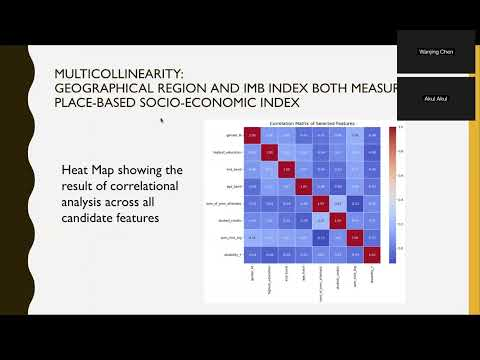

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo("aP3A3_tetsw", width=560, height=315)


In [ ]:
from IPython.display import HTML

HTML('<a href="https://youtu.be/aP3A3_tetsw" target="_blank">Open this Video on YouTube</a>')
